In [1]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
sys.path.append('/Users/mariana/Documents/projects/Huawei/tdsurv/lib')


from deep_lambda_cox import DeepLambdaSA

from utils import concordance_index, unroll_time, unroll, score
import yaml
import jax
import jax.numpy as jnp
import haiku as hk
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from scipy.special import expit as sigmoid
from utils import get_targets_and_masks
import pickle

In [41]:
# Borrowed from tdsurv (https://github.com/spotify-research/tdsurv/blob/main/notebooks/random-walk-final.ipynb)
def make_generator(mat, sigma, sigma0, thetas, bias, rng):
    """Sample from a Gauss-Markov process.
    
    Initial state:
    
        x_0 = noise(sigma0)
    
    Transition dynamics:
    
        x_nxt = np.dot(mat, x) + noise(sigma)
        
    Churn probability:
    
        p = sigmoid(np.dot(x, thetas) + bias)
    """
    n_dims = mat.shape[0]
    def gen(n_samples, horizon):
        seqs = np.zeros((n_samples, horizon + 1, n_dims + 1))
        ts = np.zeros(n_samples, dtype=int)
        cs = np.zeros(n_samples, dtype=bool)
        for i in range(n_samples):
            seqs[i, 0] = np.append(sigma0 * rng.normal(size=n_dims), 1)
            ts[i] = 1
            for j in range(0, horizon):
                p = sigmoid(np.dot(seqs[i, j, :-1], thetas) + bias)
                if rng.uniform() < p:
                    break
                ts[i] += 1
                seqs[i, j + 1] = np.append(
                    np.dot(mat, seqs[i, j + 1, :-1]) + sigma * rng.normal(size=n_dims),
                    1,
                )
            if ts[i] > horizon:
                ts[i] = horizon
                cs[i] = True
        tgt_lm, hws_lm, mask_lm = get_targets_and_masks(seqs, ts, cs, landmark=True)
        return (seqs.astype(np.float32), ts, cs, tgt_lm, hws_lm, mask_lm)
    return gen

In [105]:
rng = np.random.default_rng(seed=0)

n_dims = 49
horizon = 99
d = n_dims + 1
H = horizon + 1

# Churn parameters.
thetas = rng.normal(size=n_dims)
bias = -8

# Transition dynamics.
mat = 1.0 * np.eye(n_dims)
sigma = 0.5
sigma0 = 1.0 # Affect results quite a lot


gen = make_generator(mat, sigma, sigma0, thetas, bias, rng)
seqs, ts, cs, y, hws, m = gen(n_samples=10000, horizon=horizon)

# rng = np.random.default_rng(seed=42)
# gen = make_generator(mat, sigma, sigma0, thetas, bias, rng)
# seqs_v, ts_v, cs_v, y_v, hws_v, m_v = gen(n_samples=2000, horizon=horizon)

In [116]:
cs.sum()

1599

In [117]:
cs.sum()/cs.shape[0]

0.199875

In [108]:
with open("../../SurvanData/bigrw-seqs.pkl", "wb") as f:
    pickle.dump({
        "seqs": seqs,
        "cs": cs,
        "ts": ts,
        "target": y,
        "h_ws": hws,
        "mask": m
    }, f)

In [136]:
config_path = '../configs/config_bigrw.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [137]:
config

{'dataset_name': 'big_rw',
 'axis': 2,
 'batch_size': 128,
 'learning_rate': 0.1,
 'log_interval': 1000,
 'weight_decay': 0.0,
 'num_epochs': 100,
 'output_file': '/Users/mariana/Documents/projects/Huawei/Results/{}/',
 'landmark': True,
 'target_lr': 0.1,
 'arch': {'type': 'transformer',
  'arch_kwargs': {'hidden_size': 16,
   'seq_len': 100,
   'output_dim': 8,
   'num_layers': 1,
   'dropout': 0.05}},
 'preprocessed_data': False,
 'dataset_kwargs': {'horizon': 100,
  'data_path': '/Users/mariana/Documents/projects/Huawei/SurvanData/bigrw-seqs.pkl'},
 'lambda_': 0.0,
 'num_steps': 5,
 'verbose': True}

In [138]:
# config['landmark'] = True
config['num_epochs'] = 100
config['lambda_'] = 0.0
config['target_lr'] = 0.1
# model = SA(config, seed=1)
model = DeepLambdaSA(config, seed=2)

In [139]:
model.data['seqs'].shape

(10000, 100, 50)

In [140]:
train_gen, test_gen = model.get_train_test(test_size=.8)
loss = model.train(train_gen)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [03:02<00:00,  1.82s/it]


In [141]:
# model.config.num_epochs = 20
# loss = model.train(train_gen)

In [142]:
train_gen.X.shape

(2000, 100, 50)

In [143]:
train_gen.ts.sum()

91758

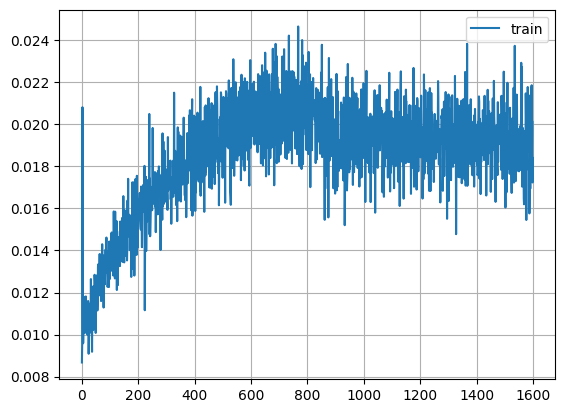

In [144]:
plt.plot(loss, label='train')
# plt.plot(loss[1], label='test')
plt.legend()
plt.grid()

In [145]:
seqs = train_gen.X
ts = train_gen.ts
cs = train_gen.cs
y = train_gen.y

scores = model.scores(seqs, q=0.0)
concordance_index(scores, ts, cs)

0.6896082276239828

In [132]:
model.state.params['linear']['b'].sum()

Array(-400.4016, dtype=float32)

In [133]:
seqs.sum()

91112.016

In [134]:
scores.sum()

Array(332.4414, dtype=float32)

In [135]:
seqs_t = test_gen.X
ts_t = test_gen.ts
cs_t = test_gen.cs
y_t = test_gen.y

scores = model.scores(seqs_t, q=0.0)
concordance_index(scores, ts_t, cs_t)

0.7426035070833009

In [14]:
ts.max()

99

In [93]:
cs.sum()/len(cs)

0.182

In [109]:
model.state

ModelState(params={'linear': {'b': Array([-2.7043428, -2.1462698, -2.6405418, -3.3836784, -2.7255018,
       -3.172235 , -3.3105652, -3.6026578, -3.6875832, -3.795933 ,
       -3.9423552, -3.9512956, -3.9544616, -3.954505 , -3.9515765,
       -3.9473665, -3.9111087, -3.8583615, -3.930731 , -3.9509144,
       -3.9286172, -3.880382 , -3.8630605, -3.904927 , -3.9359274,
       -3.9457076, -3.910614 , -3.8679276, -3.864312 , -3.935464 ,
       -3.9438832, -3.92902  , -3.9284308, -3.9094434, -3.8875754,
       -3.8614051, -3.9172504, -3.8708637, -3.9329622, -3.9322453,
       -3.8765962, -3.8447568, -3.8798735, -3.9184356, -3.9058964,
       -3.9144409, -3.9040074, -3.8864973, -3.8560956, -3.8253334,
       -3.8825145, -3.924586 , -3.9219565, -3.9275806, -3.9299843,
       -3.8837361, -3.8271053, -3.9077158, -3.916524 , -3.912597 ,
       -3.897482 , -3.9159796, -3.875676 , -3.8555703, -3.9145484,
       -3.9242039, -3.920265 , -3.9121366, -3.9138808, -3.8995707,
       -3.9106233, -3.88654